## Statistical Analysis of depression clustering.

Model used is not very good, so I manually checked all the output predictions (and checked where it missed some). It definetly revealed clustering, and then when I refined the predictions it was even clearer. Overlaying fault map shows some, but not complete correlation. Distance to fault planes does show that there is undeniable statistical correlation with fault planes; both for the main WCHF fault zone and then for the other faults present.

These depressions are not automatically related to hydrogen, the model has no idea what there origin could be; nor do I - but they show that there is some meaningful clustering. This could be related to lithology (karst?), topography, land-use, or other factors, as well as possible gas leakage. This is not a direct result, but helpful to inform further exploration.

In [43]:
import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
from scipy.ndimage import label
from scipy.stats import gaussian_kde
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path
from scipy.spatial import KDTree
import glob
import geopandas as gpd
import rasterio
import numpy as np
from scipy import ndimage


path = Path('/Users/willmcmahon/Downloads/prediction_all.tif')

plt.rcParams['font.size'] = 14

In [60]:
with rasterio.open(path) as src:
    mask = src.read(1)
    transform = src.transform
    crs = src.crs

binary = mask > 0 
labeled, num = ndimage.label(binary)

In [61]:
labeled, num

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(55000, 50000)),
 816)

In [63]:
centroids = ndimage.center_of_mass(
    binary,
    labels=labeled,
    index=np.arange(1, num + 1)
)

/var/folders/fx/yls4l5xd4cdgs4b7gy2xpdv40000gn/T/ipykernel_17958/3065979559.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hot_r = plt.cm.get_cmap('hot_r')


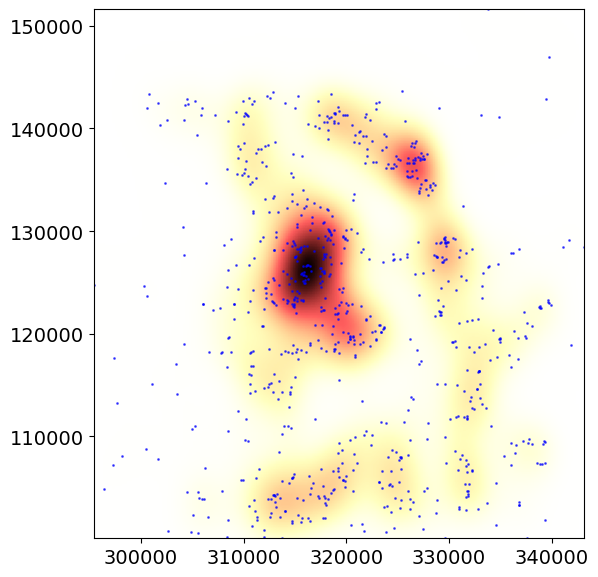

: 

In [ ]:
from rasterio.transform import xy

xs, ys = [], []

for r, c in centroids:
    x, y = xy(transform, r, c)
    xs.append(x)
    ys.append(y)
    
coords = np.array([xy(transform, r, c) for r, c in centroids])

kde = gaussian_kde(coords.T, bw_method=0.2) 

x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
y_min, y_max = coords[:, 1].min(), coords[:, 1].max()
grid_x, grid_y = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
grid_coords = np.vstack([grid_x.ravel(), grid_y.ravel()])
kde_vals = kde(grid_coords).reshape(200, 200)

fig, ax = plt.subplots(figsize=(8, 6))
from matplotlib.colors import LinearSegmentedColormap

hot_r = plt.cm.get_cmap('hot_r')
colors = hot_r(np.linspace(0, 1, 256))
colors[:, 3] = np.linspace(0, 1, 256)  # alpha ramps up with intensity

cmap = LinearSegmentedColormap.from_list('hot_r_alpha', colors)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
ax.imshow(kde_vals.T, origin='lower',
          extent=[x_min, x_max, y_min, y_max],
          cmap=cmap,  
          alpha=1)
ax.scatter(coords[:, 0], coords[:, 1], s=1, c='blue', alpha=0.6)

plt.tight_layout()
plt.savefig('kde_plot.svg', format='svg', transparent=True, bbox_inches='tight')